In [1]:
# %%capture
# aaa
import pandas as pd
from pandas.api.types import is_integer_dtype as is_integer
from pandas.api.types import is_float_dtype as is_float

import numpy as np

import time

from google.cloud import bigquery

import xgboost as xgb
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, KFold, StratifiedKFold

from sklearn.feature_selection import RFECV

from sklearn.metrics import auc, average_precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, make_scorer, precision_recall_curve, PrecisionRecallDisplay, roc_auc_score

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns

import random
import torch
import optuna
import os
import re
import gc
import shap
import logging
import optuna

### Callable Functions

In [2]:
def plot_lift_curve(y_val, y_pred, step=0.01):
    
    #Define an auxiliar dataframe to plot the curve
    aux_lift = pd.DataFrame()
    #Create a real and predicted column for our new DataFrame and assign values
    aux_lift['real'] = y_val
    aux_lift['predicted'] = y_pred
    #Order the values for the predicted probability column:
    aux_lift.sort_values('predicted',ascending=False,inplace=True)
    
    #Create the values that will go into the X axis of our plot
    x_val = np.arange(step,1+step,step)
    #Calculate the ratio of ones in our data
    ratio_ones = aux_lift['real'].sum() / len(aux_lift)
    #Create an empty vector with the values that will go on the Y axis our our plot
    y_v = []
    
    #Calculate for each x value its correspondent y value
    for x in x_val:
        num_data = int(np.ceil(x*len(aux_lift))) #The ceil function returns the closest integer bigger than our number 
        data_here = aux_lift.iloc[:num_data,:]   # ie. np.ceil(1.4) = 2
        ratio_ones_here = data_here['real'].sum()/len(data_here)
        y_v.append(ratio_ones_here / ratio_ones)
           
   #Plot the figure
    fig, axis = plt.subplots()
    fig.figsize = (40,40)
    axis.plot(x_val, y_v, 'g-', linewidth = 3, markersize = 5)
    axis.plot(x_val, np.ones(len(x_val)), 'k-')
    axis.set_xlabel('Proportion of sample')
    axis.set_ylabel('Lift')
    plt.title('Lift Curve')
    plt.show()

In [3]:
os.environ['KMP_DUPLICATE_LIB_OK']='True'

client = bigquery.Client()

### Load Data

In [33]:
# Get outcome
sql = """
SELECT
    a.*
    , b.tenure_yr1
    , b.coa_population_category
FROM 
    `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_OOT_existing_scores` AS a
LEFT JOIN
    `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_OOT_non_embedding_features` AS b
        ON a.asdb_member_key = b.asdb_member_key
WHERE 1 = 1
"""
df_og = client.query(sql).to_dataframe() 

df_og.shape

(2191637, 10)

In [5]:
# Get features
sql = """
SELECT
    *
FROM
    `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_OOT_outcome_ip`
WHERE 1 = 1
"""
outcomes = client.query(sql).to_dataframe() 
outcomes.shape

(2191613, 8)

In [34]:
df_og = df_og.rename(columns={"emr_id": "individual_id"})

In [35]:
df = outcomes.merge(df_og, on='asdb_member_key', how='left')

In [8]:
df.shape
df.head()

,asdb_member_key,index_dt,acute_ip_flag,sum_acute_ip_admits,sum_acute_calc_los,sum_acute_admit_los,sum_acute_paid_los,sum_acute_ip_cost,ip_risk,cdpsrx_scr,ip_rnk,cdpsrx_rnk,run_dt,final_score,final_riskstrat,tenure_yr1
0,72788228,2023-11-01,0,0.0,0,0,0,0E-9,0.014664,0.499227,69.8,45.4,2023-11-01,45.4,Low,12
1,72725571,2023-11-01,0,0.0,0,0,0,0E-9,0.008262,0.499227,25.6,51.3,2023-11-01,25.6,Low,13
2,72589383,2023-11-01,0,0.0,0,0,0,0E-9,0.007433,0.476756,14.2,11.1,2023-11-01,11.1,Low,13
3,72741393,2023-11-01,0,0.0,0,0,0,0E-9,0.007710,0.476756,17.9,13.0,2023-11-01,13.0,Low,13
4,72500790,2023-11-01,0,0.0,0,0,0,0E-9,0.009297,0.618880,39.2,68.6,2023-11-01,39.2,Low,11


In [9]:
def check_label_distribution(y):
    # Count the number of occurrences of each label 
    count_0 = (y == 0).sum()
    count_1 = (y == 1).sum()
    ratio = count_1 / count_0 if count_0 != 0 else np.inf
    print(count_0, count_1, ratio)
    #return count_0, count_1, ratio

print("Nov 2023 outcomes:")
check_label_distribution(df['acute_ip_flag'])

Nov 2023 outcomes:
2159654 31983 0.014809316677578909


In [10]:
df['rnk_scr'] = df['ip_rnk']/100

In [11]:
def calculate_metrics(baseline):
    # Probabilities of the positive class
    y_pred_test = df['ip_risk']
    y_test = df['acute_ip_flag']

    # Resetting the index of y_test for alignment
    y_test_reset = y_test.reset_index(drop=True)

    # ROC AUC Score
    roc_auc_test = roc_auc_score(y_test, y_pred_test)

    # Sorting indices by predicted probabilities in descending order
    idx = np.argsort(y_pred_test)[::-1]

    # Function to calculate metrics for a given cutoff percentile
    def calculate_percentile_metrics(y_test_reset, idx, percentile):
        cutoff = int(percentile * len(y_test_reset))  # Number of data points in the top percentile
        top_indices = idx[:cutoff]  # Indices of the top percentile predictions

        # Binary predictions for the top percentile
        predictions_binary = np.zeros(len(y_test_reset), dtype=int)
        predictions_binary[top_indices] = 1

        # Confusion matrix calculation
        tn, fp, fn, tp = confusion_matrix(y_test_reset, predictions_binary, labels=[0, 1]).ravel()

        # Performance metrics
        ppv = 100 * (tp / (tp + fp)) if (tp + fp) > 0 else 0  # Positive Predictive Value
        sensitivity = 100 * (tp / (tp + fn)) if (tp + fn) > 0 else 0  # Sensitivity or Recall

        # Lift calculation
        actual_positives_top_perc = y_test_reset[top_indices].sum()
        expected_positives = y_test_reset.sum() * percentile
        lift = actual_positives_top_perc / expected_positives if expected_positives > 0 else 0

        return lift, ppv, sensitivity

    lift_1_perc, ppv_1_perc, sensitivity_1_perc = calculate_percentile_metrics(y_test_reset, idx, 0.01)
    lift_10_perc, ppv_10_perc, sensitivity_10_perc = calculate_percentile_metrics(y_test_reset, idx, 0.10)

    return roc_auc_test, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc

### Model metric checks

In [12]:
roc, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc = calculate_metrics(df)
print("ROC: ",roc)
print("1% Lift: ",lift_1_perc)
print("1% PPV: ",ppv_1_perc)
print("1% Sensitivity: ",sensitivity_1_perc)
print("10% Lift: ",lift_10_perc)
print("10% PPV: ",ppv_10_perc)
print("10% Sensitivity: ",sensitivity_10_perc)

ROC:  0.8435771355474737
1% Lift:  17.593721664634337
1% PPV:  25.675305712721297
1% Sensitivity:  17.593721664634337
10% Lift:  5.85498546102617
10% PPV:  8.544325456395468
10% Sensitivity:  58.5498546102617


Text(0.5, 427.9555555555555, 'Predicted label')

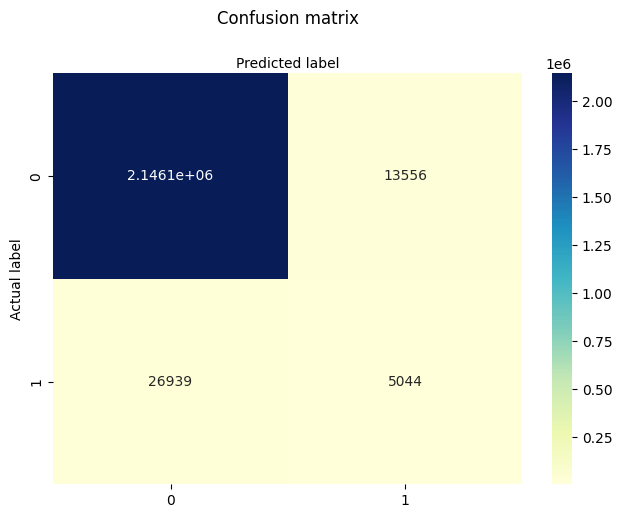

In [13]:
# Other metrics
y_pred_val = df['ip_risk']
y_pred_test_class = (y_pred_val >= .5).astype(int)
y_test = df['acute_ip_flag']

cm = confusion_matrix(y_test, y_pred_test_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [14]:
print(classification_report(y_test, y_pred_test_class))

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99   2159654
         1.0       0.27      0.16      0.20     31983

    accuracy                           0.98   2191637
   macro avg       0.63      0.58      0.60   2191637
weighted avg       0.98      0.98      0.98   2191637



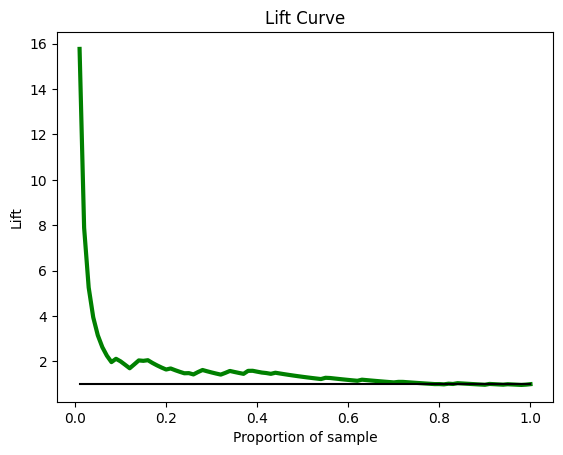

In [15]:
y_pred_val = df['ip_risk']
y_pred_test = (y_pred_val >= .5).astype(int)
plot_lift_curve(y_test, y_pred_test, step=0.01)

In [16]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_val)
# Use AUC function to calculate the area under the curve of precision recall curve
auc_precision_recall = auc(recall, precision)
print(auc_precision_recall)

0.14063258733887893


In [37]:
df['y_predict_class'] = y_pred_test_class
df['y_predict_prob'] = df['ip_risk']

In [38]:
df['acute_ip_flag'] = df['acute_ip_flag'].astype(int) 

In [39]:
df.head()

,asdb_member_key,index_dt,acute_ip_flag,sum_acute_ip_admits,sum_acute_calc_los,sum_acute_admit_los,sum_acute_paid_los,sum_acute_ip_cost,ip_risk,cdpsrx_scr,ip_rnk,cdpsrx_rnk,run_dt,final_score,final_riskstrat,tenure_yr1,coa_population_category,y_predict_class,y_predict_prob
0,72788228,2023-11-01,0,0.0,0,0,0,0E-9,0.014664,0.499227,69.8,45.4,2023-11-01,45.4,Low,12,CHIP,0,0.014664
1,72725571,2023-11-01,0,0.0,0,0,0,0E-9,0.008262,0.499227,25.6,51.3,2023-11-01,25.6,Low,13,TANF,0,0.008262
2,72589383,2023-11-01,0,0.0,0,0,0,0E-9,0.007433,0.476756,14.2,11.1,2023-11-01,11.1,Low,13,TANF,0,0.007433
3,72741393,2023-11-01,0,0.0,0,0,0,0E-9,0.007710,0.476756,17.9,13.0,2023-11-01,13.0,Low,13,TANF,0,0.007710
4,72500790,2023-11-01,0,0.0,0,0,0,0E-9,0.009297,0.618880,39.2,68.6,2023-11-01,39.2,Low,11,TANF,0,0.009297


In [41]:
df['coa_population_category'].value_counts()

coa_population_category
TANF                     1199595
Expansion                 542029
CHIP                      143509
ABD Non Dual Non LTSS     126629
Foster                     61107
Dual Elig LTSS             30957
BH Int SMI                 28413
Dual Elig NonLTSS          15511
DD                         13925
ABD Non Dual LTSS          13200
Dual Int NonLTSS            6037
Dual Int LTSS               3816
LTSS Only                   2767
DSNP Medicare Only          1981
Dual Int DD                 1305
Other                        657
BH Only                      199
Name: count, dtype: int64

In [49]:
def lift_chart(df):
    avg_tgt = df['acute_ip_flag']/len(df['acute_ip_flag'])
    df_data = df.copy()
    df_data['Actual'] = df['acute_ip_flag']
    df_data['Predict'] = df['ip_risk']>=0.5
    df_data['Prob_1'] = df['ip_risk']
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Decile']=pd.qcut(df_data.index,100,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Decile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum(numeric_only=True).Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(df['acute_ip_flag']))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df   

In [24]:
m0_3 = df.loc[df['tenure_yr1'].isin([0,1,2,3,])]
m4_8 = df.loc[df['tenure_yr1'].isin([4,5,6,7,8,])]
m_9_13 = df.loc[df['tenure_yr1'].isin([9,10,11,12,13,])]

In [48]:
ABD = df.loc[df['coa_population_category'].isin(["ABD Non Dual Non LTSS", "DD"])]
TANF = df.loc[df['coa_population_category'].isin(["TANF"])]
CHIP = df.loc[df['coa_population_category'].isin(["CHIP"])]
EXPANSION = df.loc[df['coa_population_category'].isin(["Expansion"])]

In [21]:
lift_chart(df)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,1.000000,0.458843,5628,21917,1.000029,17.596848,17.596848,1.000029,17.596343
1,0.458835,0.295457,3074,21916,0.999983,9.611356,27.208204,2.000012,13.604021
2,0.295447,0.220337,2165,21917,1.000029,6.769221,33.977426,3.000041,11.325655
3,0.220336,0.177270,1697,21916,0.999983,5.305944,39.283369,4.000024,9.820784
4,0.177265,0.148917,1407,21916,0.999983,4.399212,43.682581,5.000007,8.736504
...,...,...,...,...,...,...,...,...,...
95,0.007040,0.006811,28,21916,0.999983,0.087547,99.036988,95.999976,1.031636
96,0.006811,0.006433,40,21916,0.999983,0.125066,99.162055,96.999959,1.022290
97,0.006433,0.005319,39,21917,1.000029,0.121940,99.283995,97.999988,1.013102
98,0.005319,0.000000,55,21916,0.999983,0.171966,99.455961,98.999971,1.004606


In [29]:
lift_chart(m0_3)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.999503,0.288897,39,377,1.000292,7.442748,7.442748,1.000292,7.440576
1,0.288652,0.190506,42,377,1.000292,8.015267,15.458015,2.000584,7.726752
2,0.190362,0.139088,24,377,1.000292,4.580153,20.038168,3.000876,6.677440
3,0.138936,0.115929,32,377,1.000292,6.106870,26.145038,4.001167,6.534352
4,0.115797,0.102047,21,377,1.000292,4.007634,30.152672,5.001459,6.028775
...,...,...,...,...,...,...,...,...,...
95,0.012927,0.012164,2,377,1.000292,0.381679,98.473282,95.998833,1.025776
96,0.012161,0.008907,5,377,1.000292,0.954198,99.427481,96.999124,1.025035
97,0.008906,0.000000,2,377,1.000292,0.381679,99.809160,97.999416,1.018467
98,0.000000,0.000000,1,377,1.000292,0.190840,100.000000,98.999708,1.010104


In [30]:
lift_chart(m4_8)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.999998,0.391676,254,1570,1.000414,10.712779,10.712779,1.000414,10.708344
1,0.391647,0.270475,162,1569,0.999777,6.832560,17.545340,2.000191,8.771831
2,0.270449,0.206291,124,1570,1.000414,5.229861,22.775200,3.000605,7.590202
3,0.206242,0.168147,119,1569,0.999777,5.018979,27.794180,4.000382,6.947881
4,0.168138,0.142634,95,1569,0.999777,4.006748,31.800928,5.000159,6.359983
...,...,...,...,...,...,...,...,...,...
95,0.011034,0.010557,5,1569,0.999777,0.210881,97.258541,95.999618,1.013114
96,0.010557,0.009889,10,1569,0.999777,0.421763,97.680304,96.999395,1.007020
97,0.009889,0.008777,15,1570,1.000414,0.632644,98.312948,97.999809,1.003195
98,0.008776,0.000000,11,1569,0.999777,0.463939,98.776887,98.999586,0.997751


In [32]:
lift_chart(m_9_13)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,1.000000,0.473176,5194,19436,1.000017,18.283582,18.283582,1.000017,18.283262
1,0.473167,0.305381,2843,19436,1.000017,10.007744,28.291326,2.000035,14.145416
2,0.305374,0.226828,2007,19435,0.999966,7.064911,35.356238,3.000001,11.785409
3,0.226828,0.182138,1524,19436,1.000017,5.364686,40.720924,4.000019,10.180184
4,0.182137,0.153051,1249,19436,1.000017,4.396649,45.117573,5.000036,9.023450
...,...,...,...,...,...,...,...,...,...
95,0.006969,0.006743,27,19436,1.000017,0.095044,99.116446,95.999981,1.032463
96,0.006743,0.006367,31,19436,1.000017,0.109124,99.225570,96.999999,1.022944
97,0.006367,0.005316,36,19435,0.999966,0.126725,99.352295,97.999965,1.013799
98,0.005316,0.000000,77,19436,1.000017,0.271050,99.623346,98.999983,1.006297


In [46]:
lift_chart(ABD)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,1.000000,0.745372,522,1406,1.000327,9.321429,9.321429,1.000327,9.318379
1,0.745244,0.587124,364,1406,1.000327,6.500000,15.821429,2.000655,7.908126
2,0.587070,0.479317,314,1405,0.999616,5.607143,21.428571,3.000270,7.142213
3,0.479195,0.405623,269,1406,1.000327,4.803571,26.232143,4.000598,6.557056
4,0.405623,0.350156,238,1405,0.999616,4.250000,30.482143,5.000213,6.096168
...,...,...,...,...,...,...,...,...,...
95,0.016344,0.015879,4,1405,0.999616,0.071429,99.642857,95.999402,1.037953
96,0.015879,0.015329,4,1406,1.000327,0.071429,99.714286,96.999730,1.027985
97,0.015329,0.014594,3,1405,0.999616,0.053571,99.767857,97.999345,1.018046
98,0.014594,0.013561,1,1406,1.000327,0.017857,99.785714,98.999673,1.007940


In [50]:
lift_chart(EXPANSION)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,1.000000,0.485863,1245,5421,1.000131,12.925664,12.925664,1.000131,12.923972
1,0.485862,0.339321,739,5420,0.999946,7.672342,20.598007,2.000077,10.298604
2,0.339316,0.263658,514,5420,0.999946,5.336379,25.934385,3.000024,8.644726
3,0.263658,0.215996,423,5421,1.000131,4.391611,30.325997,4.000155,7.581205
4,0.215993,0.184487,354,5420,0.999946,3.675249,34.001246,5.000101,6.800111
...,...,...,...,...,...,...,...,...,...
95,0.013812,0.013362,13,5420,0.999946,0.134967,99.314784,95.999845,1.034531
96,0.013362,0.012828,17,5421,1.000131,0.176495,99.491279,96.999976,1.025684
97,0.012828,0.012110,12,5420,0.999946,0.124585,99.615864,97.999923,1.016489
98,0.012110,0.011163,3,5420,0.999946,0.031146,99.647010,98.999869,1.006537


In [51]:
lift_chart(TANF)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.999503,0.106504,1081,11996,1.000004,14.665581,14.665581,1.000004,14.665520
1,0.106502,0.075162,446,11996,1.000004,6.050739,20.716321,2.000008,10.358117
2,0.075158,0.061934,314,11996,1.000004,4.259938,24.976258,3.000013,8.325385
3,0.061934,0.054188,272,11996,1.000004,3.690137,28.666395,4.000017,7.166569
4,0.054187,0.048834,226,11996,1.000004,3.066070,31.732465,5.000021,6.346467
...,...,...,...,...,...,...,...,...,...
95,0.006946,0.006790,14,11996,1.000004,0.189934,98.439832,95.999983,1.025415
96,0.006790,0.006576,26,11996,1.000004,0.352734,98.792565,96.999987,1.018480
97,0.006576,0.006233,18,11996,1.000004,0.244200,99.036766,97.999992,1.010579
98,0.006233,0.005516,23,11996,1.000004,0.312034,99.348799,98.999996,1.003523


In [52]:
lift_chart(CHIP)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.959810,0.043552,47,1436,1.000634,12.020460,12.020460,1.000634,12.012843
1,0.043548,0.033737,20,1435,0.999937,5.115090,17.135550,2.000571,8.565328
2,0.033735,0.029879,12,1435,0.999937,3.069054,20.204604,3.000509,6.733726
3,0.029876,0.027309,9,1435,0.999937,2.301790,22.506394,4.000446,5.625971
4,0.027308,0.026459,8,1435,0.999937,2.046036,24.552430,5.000383,4.910110
...,...,...,...,...,...,...,...,...,...
95,0.006521,0.006086,0,1435,0.999937,0.000000,96.675192,95.999554,1.007038
96,0.006086,0.000000,1,1435,0.999937,0.255754,96.930946,96.999491,0.999293
97,0.000000,0.000000,3,1435,0.999937,0.767263,97.698210,97.999429,0.996926
98,0.000000,0.000000,9,1435,0.999937,2.301790,100.000000,98.999366,1.010107


In [53]:
def lift_chart(df):
    avg_tgt = df['acute_ip_flag']/len(df['acute_ip_flag'])
    df_data = df.copy()
    df_data['Actual'] = df['acute_ip_flag']
    df_data['Predict'] = df['ip_risk']>=0.5
    df_data['Prob_1'] = df['ip_risk']
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Decile']=pd.qcut(df_data.index,10,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Decile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum(numeric_only=True).Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(df['acute_ip_flag']))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df 

In [45]:
lift_chart(df)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,1.000000,0.458843,5628,21917,1.000029,17.596848,17.596848,1.000029,17.596343
1,0.458835,0.295457,3074,21916,0.999983,9.611356,27.208204,2.000012,13.604021
2,0.295447,0.220337,2165,21917,1.000029,6.769221,33.977426,3.000041,11.325655
3,0.220336,0.177270,1697,21916,0.999983,5.305944,39.283369,4.000024,9.820784
4,0.177265,0.148917,1407,21916,0.999983,4.399212,43.682581,5.000007,8.736504
...,...,...,...,...,...,...,...,...,...
95,0.007040,0.006811,28,21916,0.999983,0.087547,99.036988,95.999976,1.031636
96,0.006811,0.006433,40,21916,0.999983,0.125066,99.162055,96.999959,1.022290
97,0.006433,0.005319,39,21917,1.000029,0.121940,99.283995,97.999988,1.013102
98,0.005319,0.000000,55,21916,0.999983,0.171966,99.455961,98.999971,1.004606


In [25]:
lift_chart(m0_3)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.999503,0.067912,224,3769,10.000265,42.748092,42.748092,10.000265,4.274696
1,0.067911,0.045323,69,3769,10.000265,13.167939,55.916031,20.000531,2.795727
2,0.045320,0.035443,48,3769,10.000265,9.160305,65.076336,30.000796,2.169154
3,0.035442,0.028968,45,3769,10.000265,8.587786,73.664122,40.001061,1.841554
4,0.028967,0.023278,35,3769,10.000265,6.679389,80.343511,50.001327,1.606828
5,0.023277,0.020721,12,3768,9.997612,2.290076,82.633588,59.998939,1.377251
6,0.020721,0.019231,14,3769,10.000265,2.671756,85.305344,69.999204,1.218662
7,0.019231,0.017334,19,3769,10.000265,3.625954,88.931298,79.999469,1.111649
8,0.017333,0.015291,25,3769,10.000265,4.770992,93.702290,89.999735,1.041140
9,0.015291,0.000000,33,3769,10.000265,6.297710,100.000000,100.000000,1.000000


In [26]:
lift_chart(m4_8)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.999998,0.085427,1093,15694,10.000319,46.098693,46.098693,10.000319,4.609722
1,0.085421,0.051438,392,15693,9.999681,16.533108,62.631801,20.000000,3.131590
2,0.051438,0.038532,220,15694,10.000319,9.278785,71.910586,30.000319,2.396994
3,0.038531,0.030865,164,15693,9.999681,6.916913,78.827499,40.000000,1.970687
4,0.030865,0.025149,124,15694,10.000319,5.229861,84.057360,50.000319,1.681136
5,0.025149,0.020523,98,15693,9.999681,4.133277,88.190637,60.000000,1.469844
6,0.020523,0.017300,65,15693,9.999681,2.741459,90.932096,69.999681,1.299036
7,0.017300,0.015012,53,15694,10.000319,2.235344,93.167440,80.000000,1.164593
8,0.015012,0.012718,54,15693,9.999681,2.277520,95.444960,89.999681,1.060503
9,0.012718,0.000000,108,15694,10.000319,4.555040,100.000000,100.000000,1.000000


In [27]:
lift_chart(m_9_13)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,1.000000,0.086462,17141,194357,10.000021,60.338637,60.338637,10.000021,6.033851
1,0.086462,0.045647,4187,194357,10.000021,14.738806,75.077443,20.000041,3.753864
2,0.045647,0.030184,2325,194356,9.999969,8.184314,83.261757,30.000010,2.775391
3,0.030184,0.022487,1435,194357,10.000021,5.051394,88.313151,40.000031,2.207827
4,0.022487,0.017663,930,194356,9.999969,3.273726,91.586877,50.000000,1.831738
5,0.017663,0.014108,652,194357,10.000021,2.295128,93.882005,60.000021,1.564700
6,0.014108,0.011157,573,194356,9.999969,2.017037,95.899043,69.999990,1.369987
7,0.011156,0.009065,424,194357,10.000021,1.492537,97.391580,80.000010,1.217395
8,0.009065,0.007745,322,194356,9.999969,1.133484,98.525063,89.999979,1.094723
9,0.007745,0.000000,419,194357,10.000021,1.474937,100.000000,100.000000,1.000000


In [54]:
lift_chart(ABD)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,1.000000,0.211844,2542,14056,10.000427,45.392857,45.392857,10.000427,4.539092
1,0.211839,0.123854,975,14055,9.999715,17.410714,62.803571,20.000142,3.140156
2,0.123852,0.086935,585,14055,9.999715,10.446429,73.250000,29.999858,2.441678
3,0.086932,0.064459,426,14056,10.000427,7.607143,80.857143,40.000285,2.021414
4,0.064458,0.048613,360,14055,9.999715,6.428571,87.285714,50.000000,1.745714
5,0.048613,0.038196,286,14055,9.999715,5.107143,92.392857,59.999715,1.539888
6,0.038196,0.031264,186,14056,10.000427,3.321429,95.714286,70.000142,1.367344
7,0.031264,0.024316,125,14055,9.999715,2.232143,97.946429,79.999858,1.224333
8,0.024315,0.018823,67,14055,9.999715,1.196429,99.142857,89.999573,1.101593
9,0.018823,0.000000,48,14056,10.000427,0.857143,100.000000,100.000000,1.000000


In [55]:
lift_chart(EXPANSION)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,1.000000,0.114491,4572,54203,10.000018,47.466777,47.466777,10.000018,4.746669
1,0.114491,0.071985,1544,54203,10.000018,16.029900,63.496678,20.000037,3.174828
2,0.071985,0.053882,959,54203,10.000018,9.956395,73.453073,30.000055,2.448431
3,0.053882,0.042449,704,54203,10.000018,7.308970,80.762043,40.000074,2.019047
4,0.042448,0.033997,529,54203,10.000018,5.492110,86.254153,50.000092,1.725080
5,0.033997,0.027700,433,54202,9.999834,4.495432,90.749585,59.999926,1.512495
6,0.027700,0.023438,363,54203,10.000018,3.768688,94.518272,69.999945,1.350262
7,0.023438,0.019614,260,54203,10.000018,2.699336,97.217608,79.999963,1.215221
8,0.019614,0.015938,140,54203,10.000018,1.453488,98.671096,89.999982,1.096346
9,0.015937,0.000000,128,54203,10.000018,1.328904,100.000000,100.000000,1.000000


In [56]:
lift_chart(TANF)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.999503,0.034747,3202,119960,10.000042,43.440510,43.440510,10.000042,4.344033
1,0.034747,0.023870,1105,119959,9.999958,14.991182,58.431692,20.000000,2.921585
2,0.023870,0.018751,746,119960,10.000042,10.120743,68.552435,30.000042,2.285078
3,0.018751,0.015481,563,119959,9.999958,7.638041,76.190476,40.000000,1.904762
4,0.015481,0.012958,474,119960,10.000042,6.430606,82.621083,50.000042,1.652420
5,0.012958,0.010931,379,119959,9.999958,5.141772,87.762854,60.000000,1.462714
6,0.010931,0.009519,266,119959,9.999958,3.608737,91.371591,69.999958,1.305309
7,0.009519,0.008463,226,119960,10.000042,3.066070,94.437661,80.000000,1.180471
8,0.008463,0.007508,200,119959,9.999958,2.713336,97.150997,89.999958,1.079456
9,0.007508,0.000000,210,119960,10.000042,2.849003,100.000000,100.000000,1.000000


In [57]:
lift_chart(CHIP)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.959810,0.023097,116,14351,10.000070,29.667519,29.667519,10.000070,2.966731
1,0.023097,0.019519,41,14351,10.000070,10.485934,40.153453,20.000139,2.007659
2,0.019518,0.016813,32,14351,10.000070,8.184143,48.337596,30.000209,1.611242
3,0.016813,0.014118,37,14351,10.000070,9.462916,57.800512,40.000279,1.445003
4,0.014118,0.011664,38,14351,10.000070,9.718670,67.519182,50.000348,1.350374
5,0.011663,0.009966,32,14350,9.999373,8.184143,75.703325,59.999721,1.261728
6,0.009966,0.008841,34,14351,10.000070,8.695652,84.398977,69.999791,1.205703
7,0.008841,0.008062,19,14351,10.000070,4.859335,89.258312,79.999861,1.115731
8,0.008062,0.007193,17,14351,10.000070,4.347826,93.606138,89.999930,1.040069
9,0.007193,0.000000,25,14351,10.000070,6.393862,100.000000,100.000000,1.000000
